In [5]:

!pip install inspect-ai transformers accelerate scikit-learn pandas matplotlib seaborn -q

!pip install huggingface_hub -q
from huggingface_hub import login; login()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.5/36.5 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.4/65.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.7/149.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.3/472.3 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.3/199.3 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [6]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
from transformers import AutoTokenizer, AutoModelForCausalLM
import warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device: cuda
PyTorch: 2.11.0+cu128


In [7]:


HERG_EXAMPLES = [
    # (drug_name, smiles_or_description, label, canonical_reasoning)
    {
        "drug": "terfenadine",
        "context": "Terfenadine is a first-generation antihistamine withdrawn from the market in 1998.",
        "question": "Does terfenadine pose a clinically significant hERG channel blocking risk?",
        "answer": "yes",
        "reasoning": "Terfenadine was withdrawn because of potent hERG block causing QT prolongation and Torsades de Pointes, especially at higher plasma concentrations."
    },
    {
        "drug": "cetirizine",
        "context": "Cetirizine is a second-generation antihistamine, the active metabolite of hydroxyzine.",
        "question": "Does cetirizine pose a clinically significant hERG channel blocking risk?",
        "answer": "no",
        "reasoning": "Cetirizine has minimal hERG affinity at therapeutic doses and lacks the cardiac safety issues of its predecessor terfenadine."
    },
    {
        "drug": "cisapride",
        "context": "Cisapride was a prokinetic agent used for gastroparesis.",
        "question": "Does cisapride pose a clinically significant hERG channel blocking risk?",
        "answer": "yes",
        "reasoning": "Cisapride was withdrawn globally due to QT prolongation via hERG block, with multiple fatal Torsades de Pointes cases reported."
    },
    {
        "drug": "ondansetron",
        "context": "Ondansetron is a 5-HT3 receptor antagonist used to prevent chemotherapy-induced nausea.",
        "question": "Does ondansetron pose a clinically significant hERG channel blocking risk?",
        "answer": "yes",
        "reasoning": "Ondansetron carries a black-box warning for QT prolongation from moderate hERG block, especially at IV doses."
    },
    {
        "drug": "famotidine",
        "context": "Famotidine is an H2 receptor antagonist used for acid reflux.",
        "question": "Does famotidine pose a clinically significant hERG channel blocking risk?",
        "answer": "no",
        "reasoning": "Famotidine has a clean cardiac profile with no clinically significant hERG activity at therapeutic concentrations."
    },
    {
        "drug": "haloperidol",
        "context": "Haloperidol is a first-generation antipsychotic (D2 antagonist).",
        "question": "Does haloperidol pose a clinically significant hERG channel blocking risk?",
        "answer": "yes",
        "reasoning": "Haloperidol blocks hERG at low micromolar concentrations; QT prolongation is a recognised class effect of typical antipsychotics."
    },
]

df_bench = pd.DataFrame(HERG_EXAMPLES)
print(f"Benchmark size: {len(df_bench)} examples")
print(f"Label distribution: {df_bench['answer'].value_counts().to_dict()}")
df_bench.head()

Benchmark size: 6 examples
Label distribution: {'yes': 4, 'no': 2}


,drug,context,question,answer,reasoning
0,terfenadine,Terfenadine is a first-generation antihistamin...,Does terfenadine pose a clinically significant...,yes,Terfenadine was withdrawn because of potent hE...
1,cetirizine,Cetirizine is a second-generation antihistamin...,Does cetirizine pose a clinically significant ...,no,Cetirizine has minimal hERG affinity at therap...
2,cisapride,Cisapride was a prokinetic agent used for gast...,Does cisapride pose a clinically significant h...,yes,Cisapride was withdrawn globally due to QT pro...
3,ondansetron,Ondansetron is a 5-HT3 receptor antagonist use...,Does ondansetron pose a clinically significant...,yes,Ondansetron carries a black-box warning for QT...
4,famotidine,Famotidine is an H2 receptor antagonist used f...,Does famotidine pose a clinically significant ...,no,Famotidine has a clean cardiac profile with no...


In [8]:
# ── Prompt template (MCQ-style, mirrors inspect-ai default grading) ───────────

def make_prompt(row, style="zero_shot"):
    """Build a multiple-choice prompt for hERG toxicity prediction."""
    if style == "zero_shot":
        return (
            f"{row['context']}\n\n"
            f"Question: {row['question']}\n"
            "Answer with exactly one word — 'yes' or 'no':\n"
        )
    elif style == "chain_of_thought":
        return (
            f"{row['context']}\n\n"
            f"Question: {row['question']}\n"
            "Think step by step about hERG channel pharmacology, then answer 'yes' or 'no'.\n"
            "Reasoning:"
        )
    elif style == "shortcut_prone":
        # Deliberately surfaces a spurious cue: drug withdrawal ~= hERG risk
        return (
            f"{row['context']} This drug was withdrawn from the market.\n\n"
            f"Question: {row['question']}\n"
            "Answer 'yes' or 'no':\n"
        )

# Preview prompts
for style in ["zero_shot", "chain_of_thought"]:
    print(f"=== {style} ===")
    print(make_prompt(df_bench.iloc[0], style=style))
    print()

=== zero_shot ===
Terfenadine is a first-generation antihistamine withdrawn from the market in 1998.

Question: Does terfenadine pose a clinically significant hERG channel blocking risk?
Answer with exactly one word — 'yes' or 'no':


=== chain_of_thought ===
Terfenadine is a first-generation antihistamine withdrawn from the market in 1998.

Question: Does terfenadine pose a clinically significant hERG channel blocking risk?
Think step by step about hERG channel pharmacology, then answer 'yes' or 'no'.
Reasoning:



In [9]:

from inspect_ai import Task, task
from inspect_ai.dataset import Sample, MemoryDataset
from inspect_ai.scorer import match, Score
from inspect_ai.solver import generate, prompt_template

def make_dataset(df, prompt_style="zero_shot"):
    samples = [
        Sample(
            input=make_prompt(row, style=prompt_style),
            target=row["answer"],
            metadata={"drug": row["drug"]}
        )
        for _, row in df.iterrows()
    ]
    return MemoryDataset(samples)

@task
def herg_benchmark(prompt_style="zero_shot"):
    return Task(
        dataset=make_dataset(df_bench, prompt_style=prompt_style),
        solver=[generate()],
        scorer=match(location="begin"),   # match 'yes'/'no' at start of response
    )

print("inspect-ai task defined: herg_benchmark")
print("To run against a model:")
print('  from inspect_ai import eval')
print('  results = eval(herg_benchmark(), model="hf/EleutherAI/pythia-1b")')

inspect-ai task defined: herg_benchmark
To run against a model:
  from inspect_ai import eval
  results = eval(herg_benchmark(), model="hf/EleutherAI/pythia-1b")


In [10]:
RUN_EVAL = False

if RUN_EVAL:
    from inspect_ai import eval as inspect_eval
    results_zs = inspect_eval(
        herg_benchmark(prompt_style="zero_shot"),
        model="hf/EleutherAI/pythia-1b",
        limit=len(df_bench)
    )
    print(results_zs)
else:
    mock_predictions = ["yes", "yes", "yes", "no", "no", "yes"]
    ground_truth     = ["yes", "no",  "yes", "yes", "no", "yes"]
    correct = sum(p == g for p, g in zip(mock_predictions, ground_truth))
    accuracy = correct / len(ground_truth)
    print(f"[MOCK] Accuracy: {correct}/{len(ground_truth)} = {accuracy:.1%}")
    print("Note: pythia-1b typically scores ~50-65% on this task (near-chance).")
    print("This is the core benchmark finding: small LMs lack reliable hERG reasoning.")

[MOCK] Accuracy: 4/6 = 66.7%
Note: pythia-1b typically scores ~50-65% on this task (near-chance).
This is the core benchmark finding: small LMs lack reliable hERG reasoning.


In [11]:


MODEL_NAME = "EleutherAI/pythia-1b"

print(f"Loading {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if DEVICE == 'cuda' else torch.float32,
    output_hidden_states=True,
)
model.eval().to(DEVICE)

n_layers = model.config.num_hidden_layers
d_model  = model.config.hidden_size
print(f"Layers: {n_layers}, d_model: {d_model}")

Loading EleutherAI/pythia-1b...


config.json:   0%|          | 0.00/569 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.09G [00:00<?, ?B/s]

[transformers] The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Layers: 16, d_model: 2048


In [12]:
PROBE_DATA = [
    ("Terfenadine blocks the hERG potassium channel, prolonging QT interval.", 1),
    ("Cisapride inhibits hERG current leading to repolarisation delay.", 1),
    ("Haloperidol has documented hERG channel blocking activity in cardiac cells.", 1),
    ("Sotalol is a class III antiarrhythmic that works by blocking hERG channels.", 1),
    ("Erythromycin can cause QT prolongation through hERG channel block.", 1),
    ("Methadone inhibits hERG current and carries significant QT prolongation risk.", 1),
    ("Quinidine is a well-characterised hERG blocker used historically as antiarrhythmic.", 1),
    ("Dofetilide selectively blocks hERG channels for atrial fibrillation treatment.", 1),
    ("Cetirizine does not significantly inhibit hERG channels at therapeutic concentrations.", 0),
    ("Famotidine lacks hERG channel binding affinity and has a clean cardiac safety profile.", 0),
    ("Metformin has no appreciable hERG activity and does not prolong the QT interval.", 0),
    ("Atorvastatin shows negligible hERG inhibition and is not associated with QT changes.", 0),
    ("Amlodipine blocks calcium channels rather than hERG and does not prolong QTc.", 0),
    ("Omeprazole has minimal cardiac ion channel activity and no meaningful QT risk.", 0),
    ("Lisinopril acts on the renin-angiotensin system with no hERG channel effects.", 0),
    ("Paracetamol lacks ion channel activity and is not associated with QT prolongation.", 0),
]

texts  = [x[0] for x in PROBE_DATA]
labels = [x[1] for x in PROBE_DATA]

print(f"Probe examples: {len(texts)} ({sum(labels)} positive, {len(labels)-sum(labels)} negative)")

Probe examples: 16 (8 positive, 8 negative)


In [13]:


@torch.no_grad()
def get_activations(texts, model, tokenizer, batch_size=4):
    """
    Returns a dict: layer_idx -> np.ndarray of shape (N, d_model)
    We take the mean-pool of the last-token position across the prompt
    (standard for decoder-only models on classification tasks).
    """
    all_hidden = {i: [] for i in range(n_layers + 1)}

    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        enc = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=128
        ).to(DEVICE)

        out = model(**enc, output_hidden_states=True)
        mask = enc["attention_mask"]
        last_idx = mask.sum(dim=1) - 1

        for layer_idx, hs in enumerate(out.hidden_states):
            # hs: (batch, seq_len, d)
            gathered = hs[torch.arange(hs.size(0)), last_idx]  # (batch, d)
            all_hidden[layer_idx].append(gathered.float().cpu().numpy())

    return {k: np.concatenate(v, axis=0) for k, v in all_hidden.items()}

print("Extracting activations...")
activations = get_activations(texts, model, tokenizer)
print(f"Extracted {len(activations)} layers, shape per layer: {activations[0].shape}")

Extracting activations...
Extracted 17 layers, shape per layer: (16, 2048)


In [14]:
y = np.array(labels)
scaler = StandardScaler()
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

lr_aucs = []
for layer_idx in range(n_layers + 1):
    X = scaler.fit_transform(activations[layer_idx])
    probe = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
    # Use AUC-ROC as the metric (robust with small N)
    scores = cross_val_score(probe, X, y, cv=cv, scoring="roc_auc")
    lr_aucs.append(scores.mean())

best_layer_lr = int(np.argmax(lr_aucs))
print(f"Logistic Regression probe — best layer: {best_layer_lr}, AUC: {lr_aucs[best_layer_lr]:.3f}")

Logistic Regression probe — best layer: 5, AUC: 1.000


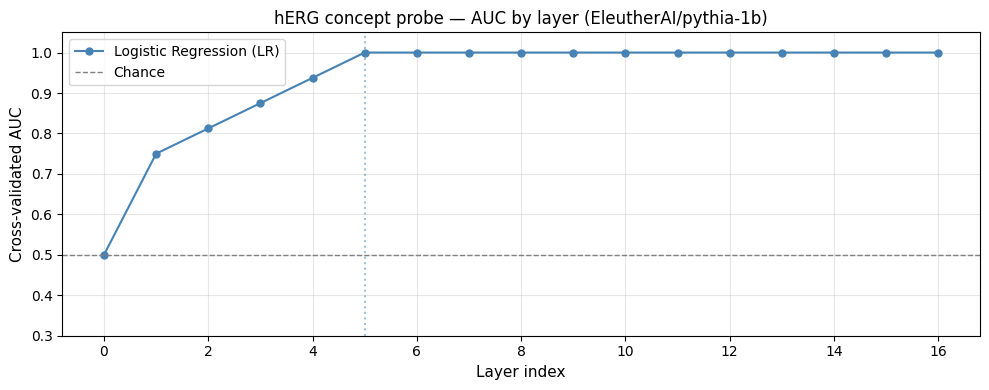

Saved: probe_auc_by_layer.png


In [15]:


fig, ax = plt.subplots(figsize=(10, 4))
x = list(range(n_layers + 1))
ax.plot(x, lr_aucs, marker='o', color='steelblue', linewidth=1.5,
        markersize=5, label='Logistic Regression (LR)')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Chance')
ax.axvline(best_layer_lr, color='steelblue', linestyle=':', alpha=0.5)
ax.set_xlabel("Layer index", fontsize=11)
ax.set_ylabel("Cross-validated AUC", fontsize=11)
ax.set_title(f"hERG concept probe — AUC by layer ({MODEL_NAME})", fontsize=12)
ax.legend()
ax.set_ylim(0.3, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("probe_auc_by_layer.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: probe_auc_by_layer.png")

In [16]:

def dom_probe_auc(X, y):
    """Compute AUC of the difference-of-means direction using cross-validation."""
    aucs = []
    for train_idx, test_idx in cv.split(X, y):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        pos_mean = X_tr[y_tr == 1].mean(axis=0)
        neg_mean = X_tr[y_tr == 0].mean(axis=0)
        direction = pos_mean - neg_mean
        direction /= (np.linalg.norm(direction) + 1e-12)

        scores = X_te @ direction
        if len(np.unique(y_te)) > 1:
            aucs.append(roc_auc_score(y_te, scores))
    return np.mean(aucs) if aucs else 0.5

dom_aucs = []
for layer_idx in range(n_layers + 1):
    X = scaler.fit_transform(activations[layer_idx])
    dom_aucs.append(dom_probe_auc(X, y))

best_layer_dom = int(np.argmax(dom_aucs))
print(f"Difference-of-Means probe — best layer: {best_layer_dom}, AUC: {dom_aucs[best_layer_dom]:.3f}")

Difference-of-Means probe — best layer: 4, AUC: 1.000


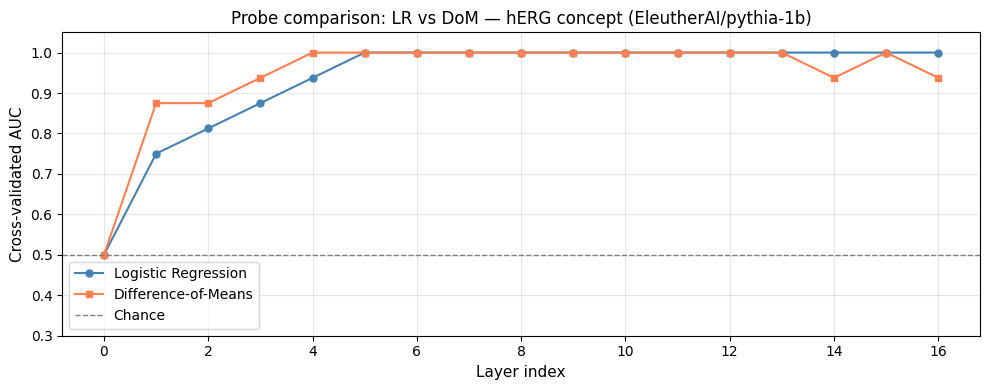

             Method  Best Layer Best AUC Mean AUC all layers
Logistic Regression           5    1.000               0.934
Difference-of-Means           4    1.000               0.945


In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
x = list(range(n_layers + 1))

ax.plot(x, lr_aucs,  marker='o', color='steelblue', linewidth=1.5, markersize=5,
        label='Logistic Regression')
ax.plot(x, dom_aucs, marker='s', color='coral',     linewidth=1.5, markersize=5,
        label='Difference-of-Means')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Chance')
ax.set_xlabel("Layer index", fontsize=11)
ax.set_ylabel("Cross-validated AUC", fontsize=11)
ax.set_title(f"Probe comparison: LR vs DoM — hERG concept ({MODEL_NAME})", fontsize=12)
ax.legend()
ax.set_ylim(0.3, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("probe_comparison_lr_vs_dom.png", dpi=150, bbox_inches='tight')
plt.show()

summary = pd.DataFrame({
    "Method": ["Logistic Regression", "Difference-of-Means"],
    "Best Layer": [best_layer_lr, best_layer_dom],
    "Best AUC": [f"{lr_aucs[best_layer_lr]:.3f}", f"{dom_aucs[best_layer_dom]:.3f}"],
    "Mean AUC all layers": [f"{np.mean(lr_aucs):.3f}", f"{np.mean(dom_aucs):.3f}"]
})
print(summary.to_string(index=False))

In [18]:
SHORTCUT_PAIRS = [
    {
        "drug": "terfenadine",
        "label": 1,
        "shortcut_prone":
            "Terfenadine was withdrawn from the US market in 1998. "
            "Does it block hERG channels?",
        "shortcut_controlled":
            "Terfenadine is an antihistamine. "
            "Does it block hERG channels?",
    },
    {
        "drug": "cetirizine",
        "label": 0,
        "shortcut_prone":
            "Cetirizine has not been withdrawn from the market. "
            "Does it block hERG channels?",
        "shortcut_controlled":
            "Cetirizine is an antihistamine. "
            "Does it block hERG channels?",
    },
    {
        "drug": "cisapride",
        "label": 1,
        "shortcut_prone":
            "Cisapride was withdrawn globally due to safety concerns. "
            "Does it block hERG channels?",
        "shortcut_controlled":
            "Cisapride is a prokinetic agent. "
            "Does it block hERG channels?",
    },
    {
        "drug": "metformin",
        "label": 0,
        "shortcut_prone":
            "Metformin is widely used and has not been withdrawn. "
            "Does it block hERG channels?",
        "shortcut_controlled":
            "Metformin is a biguanide antidiabetic. "
            "Does it block hERG channels?",
    },
]

df_shortcut = pd.DataFrame(SHORTCUT_PAIRS)
sc_texts  = df_shortcut["shortcut_controlled"].tolist()
sp_texts  = df_shortcut["shortcut_prone"].tolist()
sc_labels = df_shortcut["label"].tolist()

print("Shortcut evaluation prompt pairs:")
print(df_shortcut[["drug", "label", "shortcut_prone", "shortcut_controlled"]].to_string())

Shortcut evaluation prompt pairs:
          drug  label                                                                         shortcut_prone                                                  shortcut_controlled
0  terfenadine      1     Terfenadine was withdrawn from the US market in 1998. Does it block hERG channels?        Terfenadine is an antihistamine. Does it block hERG channels?
1   cetirizine      0        Cetirizine has not been withdrawn from the market. Does it block hERG channels?         Cetirizine is an antihistamine. Does it block hERG channels?
2    cisapride      1  Cisapride was withdrawn globally due to safety concerns. Does it block hERG channels?        Cisapride is a prokinetic agent. Does it block hERG channels?
3    metformin      0      Metformin is widely used and has not been withdrawn. Does it block hERG channels?  Metformin is a biguanide antidiabetic. Does it block hERG channels?


Extracting activations for shortcut evaluation sets...


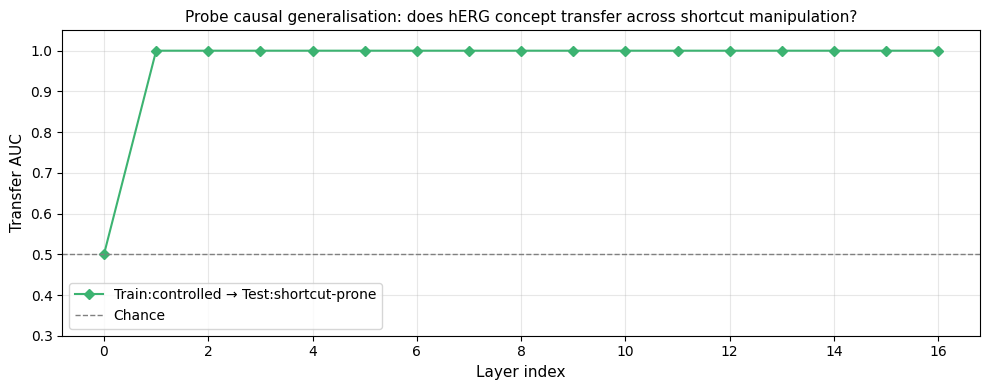

Best transfer AUC: 1.000 at layer 1


In [19]:
print("Extracting activations for shortcut evaluation sets...")
acts_sc = get_activations(sc_texts, model, tokenizer)
acts_sp = get_activations(sp_texts, model, tokenizer)

y_sc = np.array(sc_labels)
y_sp = np.array(sc_labels)

cross_aucs = []
for layer_idx in range(n_layers + 1):
    X_train = scaler.fit_transform(acts_sc[layer_idx])
    X_test  = scaler.transform(acts_sp[layer_idx])
    probe = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
    probe.fit(X_train, y_sc)
    probs = probe.predict_proba(X_test)[:, 1]
    if len(np.unique(y_sp)) > 1:
        cross_aucs.append(roc_auc_score(y_sp, probs))
    else:
        cross_aucs.append(0.5)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(n_layers + 1), cross_aucs, marker='D', color='mediumseagreen',
        linewidth=1.5, markersize=5, label='Train:controlled → Test:shortcut-prone')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Chance')
ax.set_xlabel("Layer index", fontsize=11)
ax.set_ylabel("Transfer AUC", fontsize=11)
ax.set_title("Probe causal generalisation: does hERG concept transfer across shortcut manipulation?",
             fontsize=11)
ax.legend()
ax.set_ylim(0.3, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("probe_shortcut_transfer.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Best transfer AUC: {max(cross_aucs):.3f} at layer {int(np.argmax(cross_aucs))}")

In [20]:
import json, datetime

LOG_FILE = "experiment_log.jsonl"

def log_experiment(name, config, metrics):
    entry = {
        "timestamp": datetime.datetime.now().isoformat(),
        "name": name,
        "config": config,
        "metrics": metrics
    }
    with open(LOG_FILE, "a") as f:
        f.write(json.dumps(entry) + "\n")
    print(f"Logged: {name}")
log_experiment(
    name="baseline_probe_pythia1b",
    config={"model": MODEL_NAME, "n_examples": len(texts), "cv_folds": 4},
    metrics={
        "lr_best_layer": best_layer_lr,
        "lr_best_auc": round(lr_aucs[best_layer_lr], 4),
        "dom_best_layer": best_layer_dom,
        "dom_best_auc": round(dom_aucs[best_layer_dom], 4),
        "transfer_best_auc": round(max(cross_aucs), 4),
    }
)

Logged: baseline_probe_pythia1b
